<a href="https://colab.research.google.com/github/PRAJINFO/becks-cognitive-triad-classification-language-models/blob/seven_models_five_prompts/MinistralModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
train_path = './train.json'
train_df = pd.read_json(train_path, lines=True)
# Calculate descriptive statistics for sentence length
train_df['sentence_length'] = train_df['sentence'].str.len()
print(train_df['sentence_length'].describe())
train_df

count    4197.000000
mean       44.243269
std        24.810697
min         9.000000
25%        28.000000
50%        37.000000
75%        53.000000
max       267.000000
Name: sentence_length, dtype: float64


,label,sentence,sentence_length
0,2,my friends will judge me .,26
1,3,i will cut out toxic people in my life if that...,64
2,2,i don't know how things will turn out .,39
3,4,you're not one of a kind !,26
4,1,things are getting better everyday .,37
...,...,...,...
4192,5,he has a very witty attitude .,30
4193,5,her trek was an exciting adventure .,36
4194,0,i am a danger .,15
4195,3,they will appreciate me .,25


In [ ]:
test_path = './test.json'
test_df = pd.read_json(test_path, lines=True)
test_df['sentence_length'] = test_df['sentence'].str.len()
print(test_df['sentence_length'].describe())
test_df

count    900.000000
mean      45.178889
std       25.951615
min        9.000000
25%       28.000000
50%       38.000000
75%       54.000000
max      212.000000
Name: sentence_length, dtype: float64


,label,sentence,sentence_length
0,5,he is an exceptional activist for the rights o...,73
1,1,i can feel happy on stage because i'm on red...,56
2,3,i will keep my heart open to other possibiliti...,50
3,1,i'm on top of the world .,27
4,3,i will be more productive with my time and not...,62
...,...,...,...
895,4,she is a constant source of annoyance for thos...,60
896,2,i will always be a quitter .,28
897,3,i will stay open to new adventures in my life .,47
898,5,they communicate honestly .,27


In [ ]:
from google.colab import userdata
import os
from openai import OpenAI

# Get OpenRouter API key
OPENROUTER_API_KEY = userdata.get('OpenRouter_API_Key')

def get_client():
    return OpenAI(
        base_url="https://openrouter.ai/api/v1",
        api_key=OPENROUTER_API_KEY
    )

In [ ]:
client = get_client()

response = client.chat.completions.create(
    model="mistralai/ministral-3b-2512",
    messages=[
        {"role": "user", "content": "Hello Ministral, tell me a joke."}
    ]
)
print(response.choices[0].message.content)

Of course! Here’s one for you:

**Why don’t skeletons fight each other?**
*Because they don’t have the guts!* 😄

(Or, if you prefer a techy one: Why did the neural network break up with its love interest? *It found someone with more backpropagation!*)


In [ ]:
import time

def classify_dataframe(df: pd.DataFrame, text_col="sentence"):
    label_ids, label_names = [], []
    for i, text in enumerate(df[text_col]):
        result = classify_sentence(text)
        label_ids.append(result["label_id"])
        label_names.append(result["label_name"])
        print(f"[{i+1}/{len(df)}] done:", result["label_name"])
        time.sleep(2)
    df["pred_label_id"] = label_ids
    df["pred_label_name"] = label_names
    return df

ZERO-SHOT PROMPT

In [ ]:
import json
import pandas as pd
from google import genai
import os
import re


LABELS = {
    0: "negative self",
    1: "positive self",
    2: "negative future",
    3: "positive future",
    4: "negative world",
    5: "positive world",
}

SYSTEM_PROMPT = """
Classify the given text according to Beck’s Cognitive Triad categories. Choose one from:
        0: negative self
        1: positive self
        2: negative future
        3: positive future
        4: negative world
        5: positive world
        Return only one JSON object in this format:
        {"label_id": "X", "label_name": "label_name"}

"""

VALID_LABEL_IDS = {"0", "1", "2", "3", "4", "5"}

def extract_json_from_text(text: str):
    match = re.search(r'\{.*\}', text, re.DOTALL)
    if match:
        try:
            result = json.loads(match.group())

            if result.get("label_id") in VALID_LABEL_IDS:
                return result
            else:
                print(f"Invalid label_id: {result.get('label_id')}")
                return None
        except json.JSONDecodeError:
            return None
    return None


def classify_sentence(sentence: str):
    client = get_client()
    prompt = SYSTEM_PROMPT + "\n\nSentence:\n" + sentence
    response = client.chat.completions.create(
        model="mistralai/ministral-3b-2512",
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0
    )

    result = extract_json_from_text(response.choices[0].message.content)
    if result:
        return result
    else:
        print("Invalid output, raw:", response.choices[0].message.content)
        return None

def classify_dataframe(df: pd.DataFrame, text_col="sentence"):
    label_ids, label_names, valid_indices = [], [], []

    for idx, text in enumerate(df[text_col]):
        result = classify_sentence(text)
        if result is not None:
            label_ids.append(result["label_id"])
            label_names.append(result["label_name"])
            valid_indices.append(idx)
        else:
            print(f"Excluding row {idx}: invalid prediction")

    df_valid = df.iloc[valid_indices].copy()
    df_valid["pred_label_id"] = label_ids
    df_valid["pred_label_name"] = label_names

    print(f"\nValid: {len(df_valid)}/{len(df)} ({len(df_valid)/len(df)*100:.1f}%)")
    print(f"Excluded: {len(df) - len(df_valid)}")

    return df_valid

results_df = classify_dataframe(test_df.head(900))
print(results_df.head())
results_df.to_csv("predictions.csv", index=False)


Valid: 900/900 (100.0%)
Excluded: 0
   label                                           sentence  sentence_length  \
0      5  he is an exceptional activist for the rights o...               73   
1      1   i can feel happy on stage because i'm  on red...               56   
2      3  i will keep my heart open to other possibiliti...               50   
3      1                         i'm on top of the world .                27   
4      3  i will be more productive with my time and not...               62   

  pred_label_id  pred_label_name  
0             5   positive world  
1             1    positive self  
2             3  positive future  
3             5   positive world  
4             3  positive future  


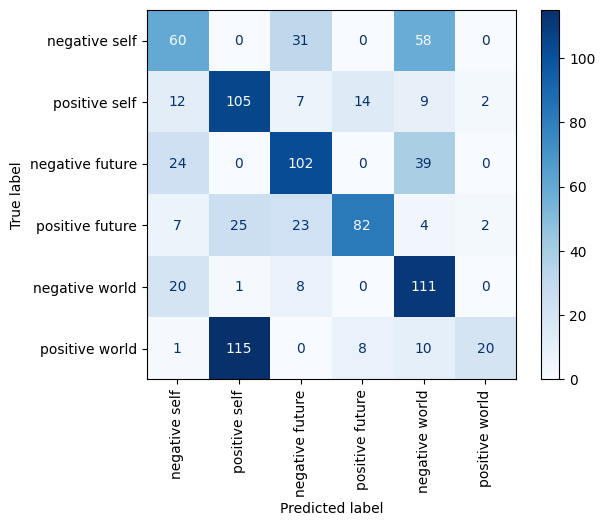

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(results_df['label'].map(LABELS), results_df['pred_label_name'], labels=list(LABELS.values()))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(LABELS.values()))
disp.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=90)
plt.show()

In [ ]:
from sklearn.metrics import classification_report
report = classification_report(results_df['label'].map(LABELS), results_df['pred_label_name'], target_names=list(LABELS.values()))
print(report)

                 precision    recall  f1-score   support

  negative self       0.60      0.62      0.61       165
  positive self       0.48      0.40      0.44       149
negative future       0.48      0.79      0.60       140
positive future       0.79      0.57      0.66       143
 negative world       0.43      0.70      0.53       149
 positive world       0.83      0.13      0.22       154

       accuracy                           0.53       900
      macro avg       0.60      0.54      0.51       900
   weighted avg       0.60      0.53      0.51       900



ZERO-SHOT + GUIDE

In [ ]:
##prompt
import json
import pandas as pd
from google import genai
import os
import re


LABELS = {
    0: "negative self",
    1: "positive self",
    2: "negative future",
    3: "positive future",
    4: "negative world",
    5: "positive world",
}

SYSTEM_PROMPT = """
Classify the following sentence into exactly one of the six categories below
according to Beck’s Cognitive Triad categories.

Categories:
0: negative self
1: positive self
2: negative future
3: positive future
4: negative world
5: positive world

Guidelines:

- "Self" refers to thoughts about oneself (e.g., "I am useless.")
- "World" refers to thoughts about others, society, or environment (e.g., "People are cruel.")
- "Future" refers to expectations or predictions (e.g., "Things will never get better.")
- "Negative" means pessimistic, self-blaming, hopeless, or critical.
- "Positive" means optimistic, self-affirming, hopeful, or appreciative.
- Choose only one label per input.
- Do not explain or add commentary.

Output rule:
Return exactly one JSON line in this format:
{"label_id": "X", "label_name": "label_name"}

Example format only (not a hint):
{"label_id": "2", "label_name": "negative future"}

Now classify the following message:
{sentence}

"""

VALID_LABEL_IDS = {"0", "1", "2", "3", "4", "5"}

def extract_json_from_text(text: str):
    match = re.search(r'\{.*\}', text, re.DOTALL)
    if match:
        try:
            result = json.loads(match.group())

            if result.get("label_id") in VALID_LABEL_IDS:
                return result
            else:
                print(f"Invalid label_id: {result.get('label_id')}")
                return None
        except json.JSONDecodeError:
            return None
    return None


def classify_sentence(sentence: str):
    client = get_client()
    prompt = SYSTEM_PROMPT + "\n\nSentence:\n" + sentence
    response = client.chat.completions.create(
        model="mistralai/ministral-3b-2512",
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0
    )

    result = extract_json_from_text(response.choices[0].message.content)
    if result:
        return result
    else:
        print("Invalid output, raw:", response.choices[0].message.content)
        return None

def classify_dataframe(df: pd.DataFrame, text_col="sentence"):
    label_ids, label_names, valid_indices = [], [], []

    for idx, text in enumerate(df[text_col]):
        result = classify_sentence(text)
        if result is not None:
            label_ids.append(result["label_id"])
            label_names.append(result["label_name"])
            valid_indices.append(idx)
        else:
            print(f"Excluding row {idx}: invalid prediction")

    df_valid = df.iloc[valid_indices].copy()
    df_valid["pred_label_id"] = label_ids
    df_valid["pred_label_name"] = label_names

    print(f"\nValid: {len(df_valid)}/{len(df)} ({len(df_valid)/len(df)*100:.1f}%)")
    print(f"Excluded: {len(df) - len(df_valid)}")

    return df_valid

results_df = classify_dataframe(test_df.head(900))
print(results_df.head())
results_df.to_csv("predictions.csv", index=False)


Valid: 900/900 (100.0%)
Excluded: 0
   label                                           sentence  sentence_length  \
0      5  he is an exceptional activist for the rights o...               73   
1      1   i can feel happy on stage because i'm  on red...               56   
2      3  i will keep my heart open to other possibiliti...               50   
3      1                         i'm on top of the world .                27   
4      3  i will be more productive with my time and not...               62   

  pred_label_id  pred_label_name  
0             1    positive self  
1             1    positive self  
2             3  positive future  
3             5   positive world  
4             3  positive future  


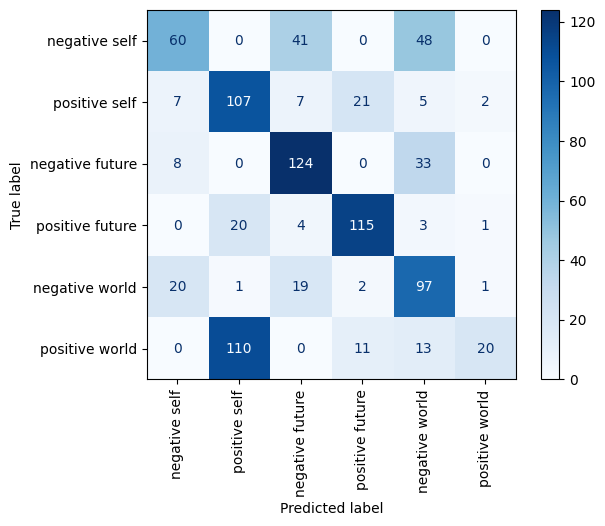

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(results_df['label'].map(LABELS), results_df['pred_label_name'], labels=list(LABELS.values()))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(LABELS.values()))
disp.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=90)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(results_df['label'].map(LABELS), results_df['pred_label_name'], target_names=list(LABELS.values()))

print(report)

                 precision    recall  f1-score   support

  negative self       0.64      0.75      0.69       165
  positive self       0.63      0.40      0.49       149
negative future       0.49      0.69      0.57       140
positive future       0.77      0.80      0.79       143
 negative world       0.45      0.72      0.55       149
 positive world       0.83      0.13      0.22       154

       accuracy                           0.58       900
      macro avg       0.63      0.58      0.55       900
   weighted avg       0.64      0.58      0.55       900



FEW-SHOT

In [ ]:
import json
import pandas as pd
from google import genai
import os
import re
import time


LABELS = {
    0: "negative self",
    1: "positive self",
    2: "negative future",
    3: "positive future",
    4: "negative world",
    5: "positive world",
}

SYSTEM_PROMPT = """
Classify the given text according to Beck’s Cognitive Triad categories. Choose one from:
        0: negative self
        1: positive self
        2: negative future
        3: positive future
        4: negative world
        5: positive world

        Output rule:
        Return exactly one JSON line in this format:
        {"label_id": "X", "label_name": "label_name"}

        Example format only (not a hint):
        {"label_id": "2", "label_name": "negative future"}                                              Examples:

Input: "I hate myself."
Output:
{"label_id": "0", "label_name": "negative self"}

Input: "People are kind to me."
Output:
{"label_id": "5", "label_name": "positive world"}

Input: "Things will never improve."
Output:
{"label_id": "2", "label_name": "negative future"}

Output rule:
Return exactly one JSON line in this format:
{"label_id": "X", "label_name": "label_name"}

Example format only (not a hint):
{"label_id": "2", "label_name": "negative future"}

Now classify the following message:
"""

VALID_LABEL_IDS = {"0", "1", "2", "3", "4", "5"}

def extract_json_from_text(text: str):
    """Extract and validate the JSON portion of the response"""
    match = re.search(r'\{.*\}', text, re.DOTALL)
    if match:
        try:
            result = json.loads(match.group())
            # Validate both label_id and label_name
            if str(result.get("label_id")) in VALID_LABEL_IDS and "label_name" in result:
                return result
            else:
                print(f"Invalid JSON format or missing label_name in result: {result}")
                return None
        except json.JSONDecodeError:
            print(f"JSONDecodeError for content: {match.group()}")
            return None
    print(f"No valid JSON found in text: {text}")
    return None


def classify_sentence(sentence: str):
    client = get_client()
    prompt = SYSTEM_PROMPT + "\n\nSentence:\n" + sentence
    response = client.chat.completions.create(
        model="mistralai/ministral-3b-2512",
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0
    )

    result = extract_json_from_text(response.choices[0].message.content)
    if result:
        return result
    else:
        print("Invalid output, raw:", response.choices[0].message.content)
        return None

def classify_dataframe(df: pd.DataFrame, text_col="sentence"):
    label_ids, label_names, valid_indices = [], [], []

    print(f"Starting classification for {len(df)} rows...")

    for idx, text in enumerate(df[text_col]):
        result = classify_sentence(text)
        if result is not None:
            label_ids.append(result["label_id"])
            label_names.append(result["label_name"])
            valid_indices.append(idx)
        else:
            print(f"Excluding row {idx}: invalid prediction")

        # Add rate limiting to avoid hitting API limits
        time.sleep(1.0)

        if (idx + 1) % 10 == 0:
            print(f"Progress: {idx + 1}/{len(df)} processed")

    df_valid = df.iloc[valid_indices].copy()
    df_valid["pred_label_id"] = label_ids
    df_valid["pred_label_name"] = label_names

    print(f"\nValid: {len(df_valid)}/{len(df)} ({len(df_valid)/len(df)*100:.1f}%)")
    print(f"Excluded: {len(df) - len(df_valid)}")

    return df_valid

results_df = classify_dataframe(test_df.head(900))
print(results_df.head())
results_df.to_csv("predictions.csv", index=False)


Starting classification for 900 rows...
Progress: 10/900 processed
Progress: 20/900 processed
Invalid JSON format or missing label_name in result: {'label_id': 'negative world'}
Invalid output, raw: ```json
{"label_id": "4", "label_id": "negative world"}
```
Excluding row 25: invalid prediction
Progress: 30/900 processed
Progress: 40/900 processed
Invalid JSON format or missing label_name in result: {'label_id': 'negative world'}
Invalid output, raw: ```json
{"label_id": "4", "label_id": "negative world"}
```
Excluding row 46: invalid prediction
Invalid JSON format or missing label_name in result: {'label_id': 'negative world'}
Invalid output, raw: ```json
{"label_id": "4", "label_id": "negative world"}
```
Excluding row 47: invalid prediction
Progress: 50/900 processed
Invalid JSON format or missing label_name in result: {'label_id': 'negative world'}
Invalid output, raw: ```json
{"label_id": "4", "label_id": "negative world"}
```
Excluding row 52: invalid prediction
Progress: 60/900 

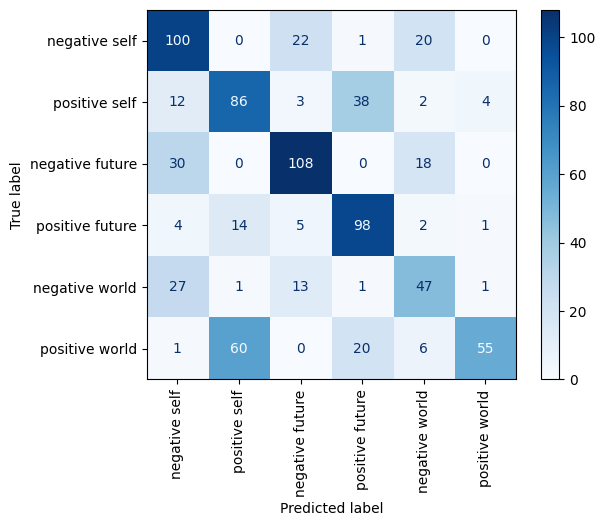

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(results_df['label'].map(LABELS), results_df['pred_label_name'], labels=list(LABELS.values()))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(LABELS.values()))
disp.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=90)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(results_df['label'].map(LABELS), results_df['pred_label_name'], target_names=list(LABELS.values()))

print(report)

                 precision    recall  f1-score   support

  negative self       0.72      0.69      0.70       156
  positive self       0.57      0.70      0.63       143
negative future       0.49      0.52      0.51        90
positive future       0.62      0.79      0.70       124
 negative world       0.53      0.59      0.56       145
 positive world       0.90      0.39      0.54       142

       accuracy                           0.62       800
      macro avg       0.64      0.61      0.61       800
   weighted avg       0.65      0.62      0.61       800



ROLE PROMPT

In [ ]:
##prompt
import json
import pandas as pd
from google import genai
import os
import re


LABELS = {
    0: "negative self",
    1: "positive self",
    2: "negative future",
    3: "positive future",
    4: "negative world",
    5: "positive world",
}

SYSTEM_PROMPT = """

You are a high-skilled clinical psychology analyst trained in Beck’s Cognitive Theory.
Classify the following message based on your professional understanding.

0: negative self
1: positive self
2: negative future
3: positive future
4: negative world
5: positive world

Output rule:
Return exactly one JSON line in this format:
{"label_id": "X", "label_name": "label_name"}
"""

VALID_LABEL_IDS = {"0", "1", "2", "3", "4", "5"}

def extract_json_from_text(text: str):
    match = re.search(r'\{.*\}', text, re.DOTALL)
    if match:
        try:
            result = json.loads(match.group())

            if str(result.get("label_id")) in VALID_LABEL_IDS:
                return result
            else:
                print(f"Invalid label_id: {result.get('label_id')}")
                return None
        except json.JSONDecodeError:
            return None
    return None


def classify_sentence(sentence: str):
    client = get_client()
    prompt = SYSTEM_PROMPT + "\n\nSentence:\n" + sentence
    response = client.chat.completions.create(
        model="mistralai/ministral-3b-2512",
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0
    )

    result = extract_json_from_text(response.choices[0].message.content)
    if result:
        return result
    else:
        print("Invalid output, raw:", response.choices[0].message.content)
        return None

def classify_dataframe(df: pd.DataFrame, text_col="sentence"):
    label_ids, label_names, valid_indices = [], [], []

    for idx, text in enumerate(df[text_col]):
        result = classify_sentence(text)
        if result is not None:
            label_ids.append(result["label_id"])
            label_names.append(result["label_name"])
            valid_indices.append(idx)
        else:
            print(f"Excluding row {idx}: invalid prediction")

    df_valid = df.iloc[valid_indices].copy()
    df_valid["pred_label_id"] = label_ids
    df_valid["pred_label_name"] = label_names

    print(f"\nValid: {len(df_valid)}/{len(df)} ({len(df_valid)/len(df)*100:.1f}%)")
    print(f"Excluded: {len(df) - len(df_valid)}")

    return df_valid

results_df = classify_dataframe(test_df.head(900))
print(results_df.head())
results_df.to_csv("predictions.csv", index=False)

Invalid label_id: 1,2
Invalid output, raw: ```json
{"label_id": "1,2", "label_name": "positive self + positive future"}
```
Excluding row 37: invalid prediction
Invalid label_id: 0, 2, 4
Invalid output, raw: ```json
{"label_id": "0, 2, 4", "label_name": "Negative self, negative future, negative world"}
```
Excluding row 190: invalid prediction

Valid: 898/900 (99.8%)
Excluded: 2
   label                                           sentence  sentence_length  \
0      5  he is an exceptional activist for the rights o...               73   
1      1   i can feel happy on stage because i'm  on red...               56   
2      3  i will keep my heart open to other possibiliti...               50   
3      1                         i'm on top of the world .                27   
4      3  i will be more productive with my time and not...               62   

  pred_label_id pred_label_name  
0             1   positive self  
1             1   positive self  
2             1   positive self  
3

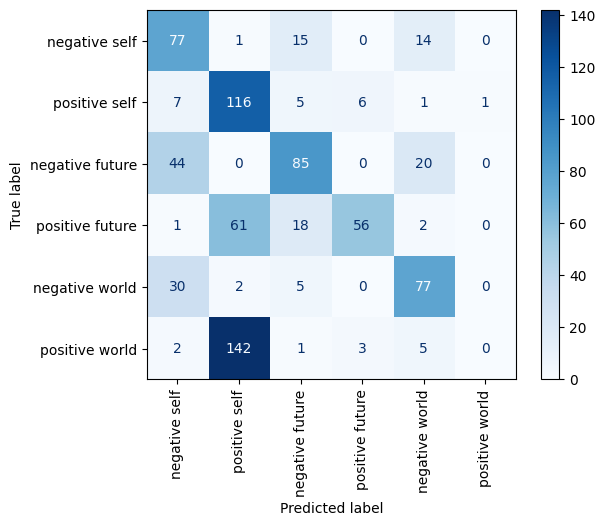

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(results_df['label'].map(LABELS), results_df['pred_label_name'], labels=list(LABELS.values()))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(LABELS.values()))
disp.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=90)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

expected_labels = list(LABELS.values())

report = classification_report(
    results_df['label'].map(LABELS),
    results_df['pred_label_name'],
    labels=expected_labels,  # Explicitly specify the labels to consider
    target_names=expected_labels # Ensure target_names match the labels parameter
)

print(report)

                 precision    recall  f1-score   support

  negative self       0.48      0.52      0.50       148
  positive self       0.36      0.78      0.49       148
negative future       0.66      0.52      0.58       165
positive future       0.86      0.39      0.54       143
 negative world       0.65      0.55      0.59       140
 positive world       0.00      0.00      0.00       154

      micro avg       0.52      0.46      0.48       898
      macro avg       0.50      0.46      0.45       898
   weighted avg       0.50      0.46      0.45       898



CHAIN OF THOUGHT PROMPT

In [ ]:
import json
import pandas as pd
import os
import re
import time
from google.colab import userdata
from openai import OpenAI

LABELS = {
    0: "negative self",
    1: "positive self",
    2: "negative future",
    3: "positive future",
    4: "negative world",
    5: "positive world",
}

VALID_LABEL_IDS = {"0", "1", "2", "3", "4", "5"}

SYSTEM_PROMPT = """
 Classify the following sentence into exactly one of the six categories below according to Beck’s Cognitive Triad categories:
 0: negative self
 1: positive self
 2: negative future
 3: positive future
 4: negative world
 5: positive world
To ensure a correct and consistent answer, please:
1.	Carefully consider the emotional polarity (positive or negative) in the input.
2.	Identify whether the message is about the self, the world, or the future.
3.	Decide the most appropriate label and explain your reasoning step by step in plain text.
Now classify the following message based on the rules below.
Output rule:
 Return exactly one JSON line in this format:
 {"label_id": "X", "label_name": "label_name"}
Example (for reference only, do not use as output for actual sentences):
 {"label_id": "2", "label_name": "negative future"}

"""

def extract_json_from_text(text: str):
    match = re.search(r'\{.*\}', text, re.DOTALL)
    if match:
        try:
            result = json.loads(match.group())
            if str(result.get("label_id")) in VALID_LABEL_IDS:
                return result
            else:
                print(f"Invalid label_id: {result.get('label_id')}")
                return None
        except json.JSONDecodeError:
            return None
    return None

def classify_sentence(sentence: str):
    client = get_client()
    prompt = SYSTEM_PROMPT + "\n\nSentence:\n" + sentence

    try:
        response = client.chat.completions.create(
            model="mistralai/ministral-3b-2512",
            messages=[{"role": "user", "content": prompt}],
            temperature=0
        )
        content = response.choices[0].message.content
        result = extract_json_from_text(content)
        if result:
            return result
        else:
            print(f"Invalid output format, raw content: {content}")
            return None
    except Exception as e:
        print(f"API Error: {e}")
        return None

def classify_dataframe(df: pd.DataFrame, text_col="sentence"):
    label_ids, label_names, valid_indices = [], [], []

    print(f"Starting classification for {len(df)} rows...")

    for idx, text in enumerate(df[text_col]):
        result = classify_sentence(text)

        if result is not None:
            label_ids.append(result["label_id"])
            label_names.append(result["label_name"])
            valid_indices.append(df.index[idx]) # Use actual index
        else:
            print(f"Excluding row {idx}: invalid prediction")

        # Fix: Rate limiting to avoid 429 errors from OpenRouter
        time.sleep(1.0)

        if (idx + 1) % 10 == 0:
            print(f"Progress: {idx + 1}/{len(df)} processed")

    df_valid = df.loc[valid_indices].copy()
    df_valid["pred_label_id"] = label_ids
    df_valid["pred_label_name"] = label_names

    print(f"\nFinal Results:")
    print(f"Valid: {len(df_valid)}/{len(df)} ({len(df_valid)/len(df)*100:.1f}%)")

    return df_valid

try:
    results_df = classify_dataframe(test_df.head(900))
    print(results_df.head())
    results_df.to_csv("predictions.csv", index=False)
    print("Saved to predictions.csv")
except NameError:
    print("Error: 'test_df' not found. Please load your dataset first.")


Starting classification for 900 rows...
Progress: 10/900 processed
Progress: 20/900 processed
Progress: 30/900 processed
Progress: 40/900 processed
Progress: 50/900 processed
Progress: 60/900 processed
Progress: 70/900 processed
Progress: 80/900 processed
Progress: 90/900 processed
Progress: 100/900 processed
Progress: 110/900 processed
Progress: 120/900 processed
Progress: 130/900 processed
Progress: 140/900 processed
Progress: 150/900 processed
Progress: 160/900 processed
Progress: 170/900 processed
Progress: 180/900 processed
Progress: 190/900 processed
Invalid output format, raw content: Let's analyze the sentence step by step:

1. **Emotional Polarity**: The sentence uses the word "fantastic," which is a strongly positive adjective. This indicates a positive emotional tone.

2. **Focus of the Message**: The sentence is about someone else ("he"), not the self, the world, or the future. It describes a positive attribute ("fantastic supporter") of an external entity.

3. **Beck’s Cog

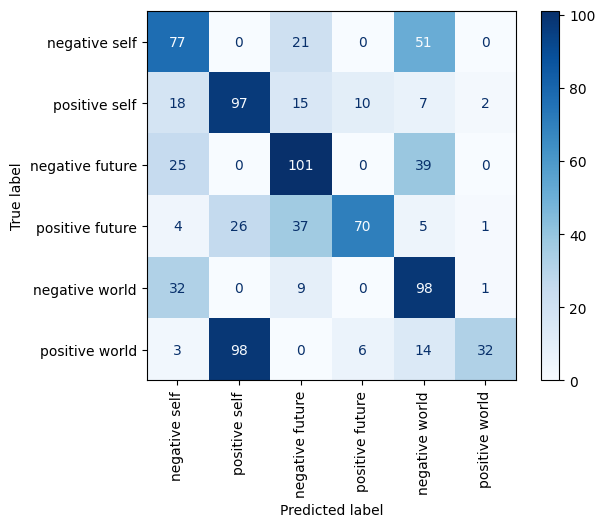

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(results_df['label'].map(LABELS), results_df['pred_label_name'], labels=list(LABELS.values()))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(LABELS.values()))
disp.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=90)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

unique_labels_in_data = sorted(results_df['pred_label_name'].unique())

report = classification_report(
    results_df['label'].map(LABELS),
    results_df['pred_label_name'],
    labels=unique_labels_in_data
)

print(report)

                 precision    recall  f1-score   support

negative future       0.55      0.61      0.58       165
  negative self       0.48      0.52      0.50       149
 negative world       0.46      0.70      0.55       140
positive future       0.81      0.49      0.61       143
  positive self       0.44      0.65      0.52       149
 positive world       0.89      0.21      0.34       153

       accuracy                           0.53       899
      macro avg       0.61      0.53      0.52       899
   weighted avg       0.61      0.53      0.52       899

